In [59]:
import networkx as nx
import numpy as np

In [60]:

G_euclid=nx.Graph()

In [61]:
G_euclid.add_nodes_from(["A","B","C","D","E"])
print(G_euclid.adj) #to actually see the adjacency structure as a dict of dicts
print(G_euclid.edges(data=True))

{'A': {}, 'B': {}, 'C': {}, 'D': {}, 'E': {}}
[]


In [62]:
gene_expression={'A': np.array([7, 9.2, 14.6, 20, 35.1]), 'B': np.array([19, 14.2, 6.6, 14.6, 18]), 'C' : np.array([8.6, 7.0, 6.5, 7.3, 8.7]), 'D' : np.array([6.8, 7.9, 5.5, 2.3, 2.9]), 'E' : np.array([0.9, 1.8, 3.9, 4.8, 6.2])}




In [63]:
import itertools

In [64]:
for g1, g2 in itertools.combinations(gene_expression.keys(), 2):
    euclidean_d = np.linalg.norm(gene_expression[g1]-gene_expression[g2])
    print(g1, g2, euclidean_d)
    if euclidean_d < 11:
        G_euclid.add_edge(g1, g2, weight=np.round(euclidean_d, 2))
    


A B 23.54930996865938
A C 30.51655288527851
A D 37.877037898969874
A E 35.6750613173965
B C 17.31444483660969
B D 23.854559312634557
B E 26.906133129827484
C D 7.980601481091509
C E 10.275699489572474
D E 9.577055915050304


In [65]:
print(G_euclid.edges(data=True))


[('C', 'D', {'weight': np.float64(7.98)}), ('C', 'E', {'weight': np.float64(10.28)}), ('D', 'E', {'weight': np.float64(9.58)})]


In [66]:
G_corr=nx.Graph()

In [67]:
for g1, g2 in itertools.combinations(gene_expression.keys(), 2):
    r_pearson=np.corrcoef(gene_expression[g1], gene_expression[g2])[0,1] #to take the off diagonal element
    print(g1, g2, r_pearson)
    if abs(r_pearson) > 0.75:
        G_corr.add_edge(g1, g2, color='red' if r_pearson > 0 else 'blue')
    
    

A B 0.1828216462864932
A C 0.3697934945410334
A D -0.8082141771478254
A E 0.9365791829329877
B C 0.8968154506323426
B D -0.09154760671740922
B E -0.11285372096379824
C D -0.20926224800853732
C E 0.06545618513053798
D E -0.8838215830121603


In [68]:
print(G_corr.edges(data=True))

[('A', 'D', {'color': 'blue'}), ('A', 'E', {'color': 'red'}), ('D', 'E', {'color': 'blue'}), ('B', 'C', {'color': 'red'})]


In [69]:
G_l1=nx.Graph()
G_l1.add_nodes_from(["A","B","C","D","E"])

In [70]:
for g1, g2 in itertools.combinations(gene_expression.keys(), 2):
    l1_norm=np.sum(np.abs(gene_expression[g1]-gene_expression[g2]))
    print(g1, g2, l1_norm)
    if l1_norm <20:
        G_l1.add_edge(g1, g2, weight=np.round(l1_norm,2))

A B 47.5
A C 51.0
A D 60.5
A E 68.3
B C 34.300000000000004
B D 47.0
B E 54.8
C D 14.499999999999998
C E 20.5
D E 19.400000000000002


In [71]:
print(G_l1.edges(data=True))

[('C', 'D', {'weight': np.float64(14.5)}), ('D', 'E', {'weight': np.float64(19.4)})]


In [72]:
def bin_equal_width(x): #this is the rule we use to make the bins, dividing range into equal sized bins
    edges = np.linspace(min(x), max(x), 4) #4 including start and end
    return np.digitize(x, edges[1:3]) #to get 3 bin values corresponding to the 2 points in edges[1:3]

In [73]:
print(bin_equal_width(gene_expression['A']))
print(bin_equal_width(gene_expression['B']))
print(bin_equal_width(gene_expression['C']))
print(bin_equal_width(gene_expression['D']))
print(bin_equal_width(gene_expression['E']))



[0 0 0 1 2]
[2 1 0 1 2]
[2 0 0 1 2]
[2 2 1 0 0]
[0 0 1 2 2]


In [74]:
def bin_equal_alternate(l): #this is a manual implementation without using the digitize function
    edges=np.linspace(min(l), max(l), 4)
    edge1=edges[1]
    edge2=edges[2]
    l_binned=[]
    for x in l:
        if x<edge1:
            l_binned.append(0)
        elif x < edge2:
            l_binned.append(1)
        else:
            l_binned.append(2)
    l_binned=np.array(l_binned)
    return l_binned
            

In [75]:
print(bin_equal_alternate(gene_expression['A']))
print(bin_equal_alternate(gene_expression['B']))
print(bin_equal_alternate(gene_expression['C']))
print(bin_equal_alternate(gene_expression['D']))
print(bin_equal_alternate(gene_expression['E']))

[0 0 0 1 2]
[2 1 0 1 2]
[2 0 0 1 2]
[2 2 1 0 0]
[0 0 1 2 2]


In [76]:
from collections import Counter

In [77]:
import math

In [78]:
def mi_function(x,y):
    n=len(x)
    count_dict=Counter(zip(x, y))
    print(count_dict)
    counter_x=Counter(x)
    counter_y=Counter(y)
    print(counter_x)
    print(counter_y)
    mi=0
    for (x_, y_), count in count_dict.items():
        p_xy=count/n
        p_x = counter_x[x_]/n
        p_y = counter_y[y_]/n
        mi+=p_xy*math.log(p_xy/(p_x*p_y))
    return mi

In [79]:
gene_expression_bins={g: bin_equal_width(v) for (g,v) in gene_expression.items()}


mi_function(gene_expression_bins['B'], gene_expression_bins['C'])
#mi_function(gene_expression['A'], gene_expression['B']) #this is not good

Counter({(np.int64(2), np.int64(2)): 2, (np.int64(1), np.int64(0)): 1, (np.int64(0), np.int64(0)): 1, (np.int64(1), np.int64(1)): 1})
Counter({np.int64(2): 2, np.int64(1): 2, np.int64(0): 1})
Counter({np.int64(2): 2, np.int64(0): 2, np.int64(1): 1})


0.7776612957621658

In [80]:
G_mi = nx.Graph()

In [81]:
gene_expression_bins={g: bin_equal_width(v) for (g,v) in gene_expression.items()}

for g1, g2 in itertools.combinations(gene_expression_bins.keys(), 2):
    mi = mi_function(gene_expression_bins[g1], gene_expression_bins[g2])
    print(g1, g2, mi)
    if mi > 0.65:
        G_mi.add_edge(g1, g2, weight=np.round(mi, 2))



Counter({(np.int64(0), np.int64(2)): 1, (np.int64(0), np.int64(1)): 1, (np.int64(0), np.int64(0)): 1, (np.int64(1), np.int64(1)): 1, (np.int64(2), np.int64(2)): 1})
Counter({np.int64(0): 3, np.int64(1): 1, np.int64(2): 1})
Counter({np.int64(2): 2, np.int64(1): 2, np.int64(0): 1})
A B 0.39575279478527825
Counter({(np.int64(0), np.int64(0)): 2, (np.int64(0), np.int64(2)): 1, (np.int64(1), np.int64(1)): 1, (np.int64(2), np.int64(2)): 1})
Counter({np.int64(0): 3, np.int64(1): 1, np.int64(2): 1})
Counter({np.int64(2): 2, np.int64(0): 2, np.int64(1): 1})
A C 0.6730116670092564
Counter({(np.int64(0), np.int64(2)): 2, (np.int64(0), np.int64(1)): 1, (np.int64(1), np.int64(0)): 1, (np.int64(2), np.int64(0)): 1})
Counter({np.int64(0): 3, np.int64(1): 1, np.int64(2): 1})
Counter({np.int64(2): 2, np.int64(0): 2, np.int64(1): 1})
A D 0.6730116670092564
Counter({(np.int64(0), np.int64(0)): 2, (np.int64(0), np.int64(1)): 1, (np.int64(1), np.int64(2)): 1, (np.int64(2), np.int64(2)): 1})
Counter({np.int

In [82]:
print(G_mi)

Graph with 5 nodes and 5 edges


In [83]:
print(G_mi.edges(data=True))

[('A', 'C', {'weight': np.float64(0.67)}), ('A', 'D', {'weight': np.float64(0.67)}), ('A', 'E', {'weight': np.float64(0.67)}), ('C', 'B', {'weight': np.float64(0.78)}), ('D', 'E', {'weight': np.float64(1.05)})]


In [84]:
import matplotlib.pyplot as plt

{'A': array([1., 0.]), 'B': array([0.30901695, 0.95105657]), 'C': array([-0.80901706,  0.58778526]), 'D': array([-0.809017  , -0.58778532]), 'E': array([ 0.3090171 , -0.95105651])}
['black', 'black', 'black']
{('C', 'D'): np.float64(7.98), ('C', 'E'): np.float64(10.28), ('D', 'E'): np.float64(9.58)}


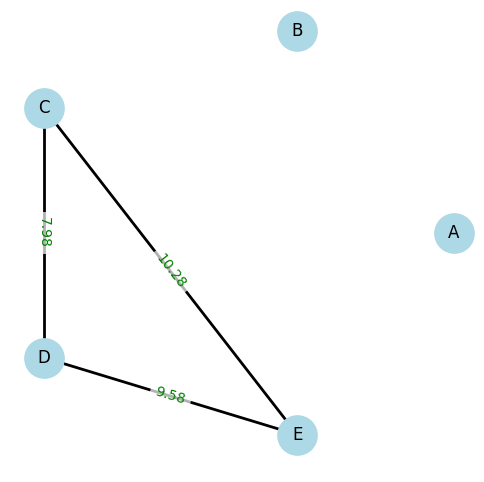

In [85]:
#very important template for NetworkX plotting

plt.figure(figsize=(6,6))
positions = nx.circular_layout(G_euclid)#this is saying where the points are in 2d plane, should use circular layout

print(positions)

# 2. Extract edge colors from metadata
edge_colors = [G_euclid[u][v].get('color', 'black') for (u, v) in G_euclid.edges()] #data=False so only the nodes come
#[u][v] is to access the metadata and color is black if no color
print(edge_colors)

# 3. Extract edge weights for labels
edge_labels = nx.get_edge_attributes(G_euclid, 'weight') #returns dict where key is the (u, v) and the value is the weight
print(edge_labels)

#now we have edge labels and edge colors both

nx.draw_networkx_nodes(G_euclid, positions, node_color='lightblue', node_size=800) #this draws the vertices

nx.draw_networkx_edges(G_euclid, pos, edge_color=edge_colors, width=2) #this draws edges

nx.draw_networkx_labels(G_euclid, pos, font_color='black') #this is the node labels, no need to specify manually

nx.draw_networkx_edge_labels(
    G_euclid,
    pos,
    edge_labels=edge_labels,
    font_color='green',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none') #this is edge labels, needs to be told using the get_edge attributes
)

plt.axis('off')
plt.savefig('euclid.png')
plt.show()

{'A': array([1., 0.]), 'D': array([0.30901695, 0.95105657]), 'E': array([-0.80901706,  0.58778526]), 'B': array([-0.809017  , -0.58778532]), 'C': array([ 0.3090171 , -0.95105651])}
['blue', 'red', 'blue', 'red']
{}


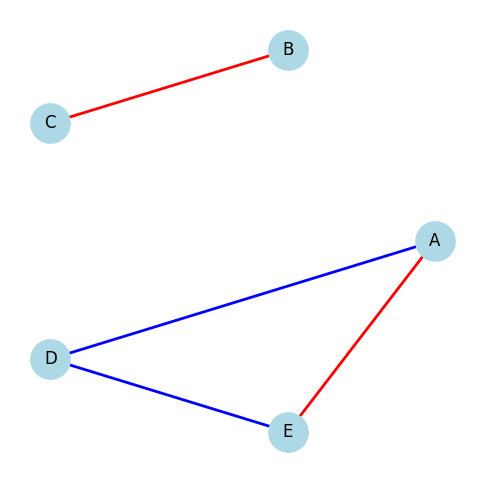

In [86]:
#very important template for NetworkX plotting

plt.figure(figsize=(6,6))
positions = nx.circular_layout(G_corr)#this is saying where the points are in 2d plane, should use circular layout

print(positions)

# 2. Extract edge colors from metadata
edge_colors = [G_corr[u][v].get('color', 'black') for (u, v) in G_corr.edges()] #data=False so only the nodes come
#[u][v] is to access the metadata and color is black if no color
print(edge_colors)

# 3. Extract edge weights for labels
edge_labels = nx.get_edge_attributes(G_corr, 'weight') #returns dict where key is the (u, v) and the value is the weight
print(edge_labels)

#now we have edge labels and edge colors both

nx.draw_networkx_nodes(G_corr, positions, node_color='lightblue', node_size=800) #this draws the vertices

nx.draw_networkx_edges(G_corr, pos, edge_color=edge_colors, width=2) #this draws edges, colors needed here

nx.draw_networkx_labels(G_corr, pos, font_color='black') #this is the node labels, no need to specify manually

nx.draw_networkx_edge_labels(
    G_corr,
    pos,
    edge_labels=edge_labels,
    font_color='green',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none') #this needs edge labels, needs to be told using the get_edge attributes
)

plt.axis('off')
plt.savefig('corr.png')
plt.show()

{'A': array([1., 0.]), 'B': array([0.30901695, 0.95105657]), 'C': array([-0.80901706,  0.58778526]), 'D': array([-0.809017  , -0.58778532]), 'E': array([ 0.3090171 , -0.95105651])}
['black', 'black']
{('C', 'D'): np.float64(14.5), ('D', 'E'): np.float64(19.4)}


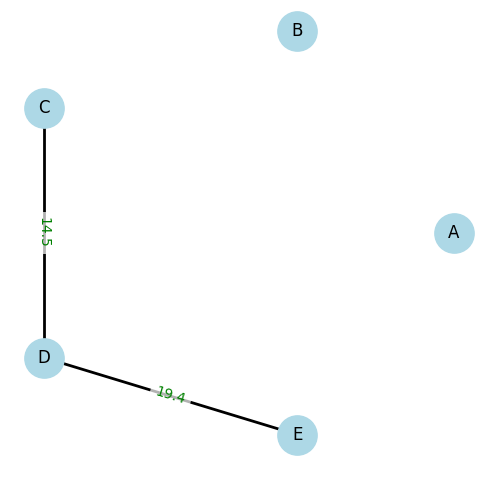

In [87]:
#very important template for NetworkX plotting

plt.figure(figsize=(6,6))
positions = nx.circular_layout(G_l1)#this is saying where the points are in 2d plane, should use circular layout

print(positions)

# 2. Extract edge colors from metadata
edge_colors = [G_l1[u][v].get('color', 'black') for (u, v) in G_l1.edges()] #data=False so only the nodes come
#[u][v] is to access the metadata and color is black if no color
print(edge_colors)

# 3. Extract edge weights for labels
edge_labels = nx.get_edge_attributes(G_l1, 'weight') #returns dict where key is the (u, v) and the value is the weight
print(edge_labels)

#now we have edge labels and edge colors both

nx.draw_networkx_nodes(G_l1, positions, node_color='lightblue', node_size=800) #this draws the vertices

nx.draw_networkx_edges(G_l1, pos, edge_color=edge_colors, width=2) #this draws edges

nx.draw_networkx_labels(G_l1, pos, font_color='black') #this is the node labels, no need to specify manually

nx.draw_networkx_edge_labels(
    G_l1,
    pos,
    edge_labels=edge_labels,
    font_color='green',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none') #this is edge labels, needs to be told using the get_edge attributes
)

plt.axis('off')
plt.savefig('l1.png')
plt.show()

{'A': array([1., 0.]), 'C': array([0.30901695, 0.95105657]), 'D': array([-0.80901706,  0.58778526]), 'E': array([-0.809017  , -0.58778532]), 'B': array([ 0.3090171 , -0.95105651])}
['black', 'black', 'black', 'black', 'black']
{('A', 'C'): np.float64(0.67), ('A', 'D'): np.float64(0.67), ('A', 'E'): np.float64(0.67), ('C', 'B'): np.float64(0.78), ('D', 'E'): np.float64(1.05)}


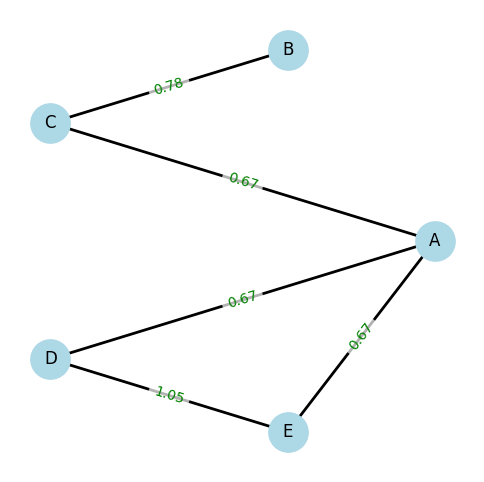

In [89]:
#very important template for NetworkX plotting

plt.figure(figsize=(6,6))
positions = nx.circular_layout(G_mi)#this is saying where the points are in 2d plane, should use circular layout or spring layout try both

print(positions)

# 2. Extract edge colors from metadata
edge_colors = [G_mi[u][v].get('color', 'black') for (u, v) in G_mi.edges()] #data=False so only the nodes come
#[u][v] is to access the metadata and color is black if no color
print(edge_colors)

# 3. Extract edge weights for labels
edge_labels = nx.get_edge_attributes(G_mi, 'weight') #returns dict where key is the (u, v) and the value is the weight
print(edge_labels)

#now we have edge labels and edge colors both

nx.draw_networkx_nodes(G_mi, positions, node_color='lightblue', node_size=800) #this draws the vertices

nx.draw_networkx_edges(G_mi, pos, edge_color=edge_colors, width=2) #this draws edges

nx.draw_networkx_labels(G_mi, pos, font_color='black') #this is the node labels, no need to specify manually

nx.draw_networkx_edge_labels(
    G_mi,
    pos,
    edge_labels=edge_labels,
    font_color='green',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none') #this is edge labels, needs to be told using the get_edge attributes
)

plt.axis('off')
plt.savefig('mi.png')
plt.show()